# Sulfur Inversion Barrier in Methylphenylsulfoxide: A DFT Functional Comparison

**Research question:** How sensitive is the pyramidal sulfur inversion 
barrier in sulfoxides to the choice of DFT functional, and what role 
does dispersion correction play?

**Motivation:** This project was inspired by the pharmacological 
relevance of sulfur chirality in modafinil, whose sulfoxide group 
determines its enantiomer-dependent activity.

**Model system:** Methylphenylsulfoxide, CH₃-S(=O)-C₆H₅

In [2]:
import sys
sys.path.append('../scripts')
from parse_orca_profile import build_profile, sanity_check, HARTREE_TO_KCAL
from pathlib import Path
import matplotlib.pyplot as plt

## Energetics: barrier comparison between two levels of theory

In [3]:
PROJECT_ROOT = Path("..")

svp_min = PROJECT_ROOT / "calculations/step3_b3lyp_opt/step3_opt.out"
svp_ts = PROJECT_ROOT / "calculations/step5_ts_search/attempt2/step5_ts_v2.out"
tzvp_min = PROJECT_ROOT / "calculations/step4_b3lyp_d3_opt/step4_opt.out"
tzvp_ts = PROJECT_ROOT / "calculations/step6_ts_search/step6_ts.out"

svp_profile = build_profile(svp_min, svp_ts, "B3LYP/def2-SVP")
tzvp_profile = build_profile(tzvp_min, tzvp_ts, "B3LYP-D3/def2-TZVP")

print("Sanity checks:")
sanity_check(svp_profile)
sanity_check(tzvp_profile)

Sanity checks:
  OK: B3LYP/def2-SVP minimum (0 imag) and TS (1 imag) both verified.
  OK: B3LYP-D3/def2-TZVP minimum (0 imag) and TS (1 imag) both verified.


True

## Results table

In [4]:
print(f"{'Level':25s} {'E(min) / Eh':>16s} {'E(TS) / Eh':>16s} {'Barrier / kcal/mol':>20s}")
print("-" * 80)
for p in (svp_profile, tzvp_profile):
    print(f"{p['label']:25s} {p['e_min']:16.6f} {p['e_ts']:16.6f} {p['barrier_kcal']:20.2f}")

diff = svp_profile['barrier_kcal'] - tzvp_profile['barrier_kcal']
print(f"\nDifference (SVP - TZVP): {diff:.2f} kcal/mol ({100*diff/svp_profile['barrier_kcal']:.1f}% relative)")

Level                          E(min) / Eh       E(TS) / Eh   Barrier / kcal/mol
--------------------------------------------------------------------------------
B3LYP/def2-SVP                 -744.283224      -744.217102                41.49
B3LYP-D3/def2-TZVP             -744.869490      -744.801781                42.49

Difference (SVP - TZVP): -1.00 kcal/mol (-2.4% relative)


## Energy profile visualization


Plot saved to: ..\results\energy_profile_notebook.png


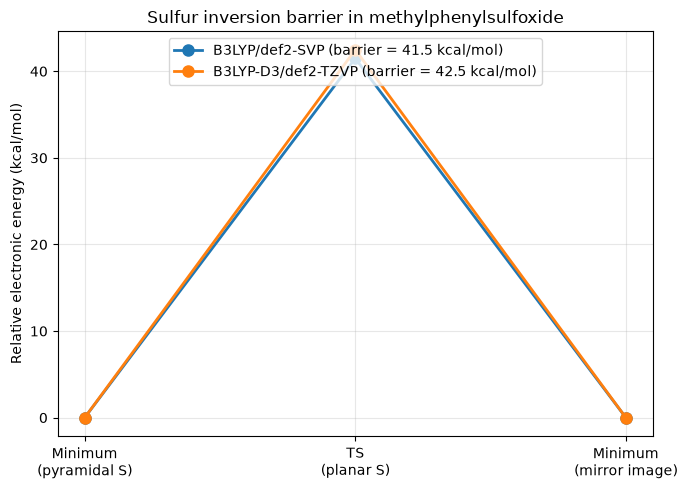

In [5]:
from parse_orca_profile import plot_profiles

plot_profiles([svp_profile, tzvp_profile], PROJECT_ROOT / "results/energy_profile_notebook.png")
plt.show()

## TS structural comparison

Both transition states were confirmed to have exactly one imaginary 
vibrational frequency (~530 cm⁻¹ at both levels), corresponding to 
the sulfur inversion motion, and IRC calculations (at the SVP level) 
confirmed that the TS connects two mirror-image (enantiomeric) 
pyramidal sulfur minima.

Key structural parameters at the TS (both perfectly planar at sulfur, 
sum of angles = 360.0°):

| Parameter      | SVP TS   | TZVP+D3 TS | Difference |
|-----------------|---------:|-----------:|-----------:|
| S-C(methyl)     | 1.806 Å  | 1.788 Å    | -0.018 Å   |
| S=O             | 1.535 Å  | 1.506 Å    | -0.029 Å   |
| S-C(ipso)       | 1.743 Å  | 1.732 Å    | -0.011 Å   |

## Conclusions

1. **Barrier magnitude**: The sulfur pyramidal inversion barrier in 
   methylphenylsulfoxide is 41.5–42.5 kcal/mol (electronic energy, 
   no ZPE correction), consistent with typical experimental and 
   computational estimates for sulfoxide inversion barriers 
   (35–45 kcal/mol range).

2. **Functional/basis sensitivity**: The barrier changes by only 
   ~1 kcal/mol (2.4%) between B3LYP/def2-SVP and B3LYP-D3/def2-TZVP. 
   This is a smaller effect than might be expected given the 
   presence of an aromatic ring and dispersion-relevant substituents 
   near the inversion center — suggesting the barrier is dominated 
   by local electronic reorganization at sulfur (sp³ → sp² 
   rehybridization) rather than by long-range dispersion interactions.

3. **Mechanistic confirmation**: Both TS structures are essentially 
   planar at sulfur (angle sum = 360.0°) at both levels of theory, 
   and IRC calculations confirm that this planar TS connects two 
   mirror-image (enantiomeric) pyramidal minima — directly verifying 
   the inversion mechanism, not just a stationary point with the 
   right number of imaginary frequencies.

4. **Practical implication**: For this type of localized 
   rehybridization reaction, the computationally cheaper 
   B3LYP/def2-SVP level already gives a qualitatively and 
   quantitatively reliable barrier, without requiring the added cost 
   of dispersion correction and a larger basis set.

## Limitations and possible extensions

- Barriers reported here are electronic energies only; ZPE and 
  thermal corrections (available in the raw ORCA output) were not 
  yet incorporated into the final barrier value.
- Only one functional family (B3LYP) was tested; comparison with a 
  range-separated hybrid (e.g. ωB97X-D3) would test sensitivity to 
  long-range exchange treatment more directly.
- IRC was only performed at the SVP level; repeating it at 
  TZVP+D3 would further strengthen the structural comparison.